In [43]:
# CS180 (CS280A): Project 1 starter Python code

# these are just some suggested libraries
# instead of scikit-image you could use matplotlib and opencv to read, write, and display images

import numpy as np
import skimage as sk
import skimage.io as skio
from skimage import img_as_ubyte
import glob
import os


In [ ]:
def align(c1, c2):
    search = 35 # searches for match up in all 4 directions, finds lowest val in loss
    #set it up so the "center" in the array is where neither image moves (at search + 1, search + 1)
    diff = np.zeros((2*search + 1, 2*search + 1))

    def loss(a1, a2):
        return np.sqrt(np.sum((a1-a2)**2))
    
    for i in range(len(diff)):
        for j in range(len(diff[0])):
            x_shift = i - search
            y_shift = j - search
            a2 = np.roll(c2, i - search, axis=0)
            a2 = np.roll(a2, j - search, axis=1)
            diff[i][j] = loss(c1, a2)
    pos = np.unravel_index(np.argmin(diff), diff.shape)
    c2 = np.roll(c2, pos[0] - search, axis=0)
    c2 = np.roll(c2, pos[1] - search, axis=1)
    return c2


/var/folders/d2/8xxcksw968qc75dtqjt32_mc0000gn/T/ipykernel_19016/2891855870.py:32: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_out)
/var/folders/d2/8xxcksw968qc75dtqjt32_mc0000gn/T/ipykernel_19016/2891855870.py:33: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


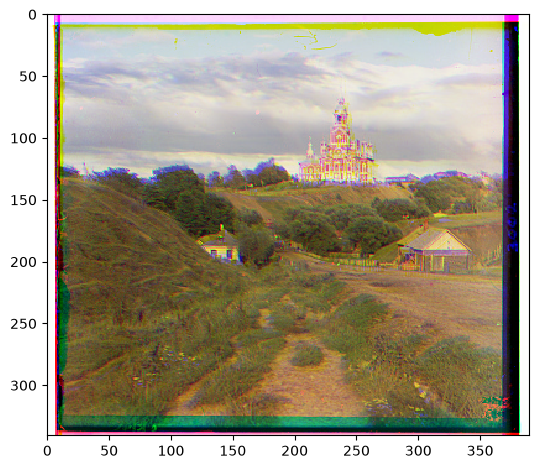

In [36]:

# name of the input file
imname = 'CS180_fa2026_proj1_data/cathedral.jpg'

# read in the image
im = skio.imread(imname)

# convert to double (might want to do this later on to save memory)    
im = sk.img_as_float(im)
    
# compute the height of each part (just 1/3 of total)
height = np.floor(im.shape[0] / 3.0).astype(int)

# separate color channels
b = im[:height]
g = im[height: 2*height]
r = im[2*height: 3*height]

# align the images
# functions that might be useful for aligning the images include:
# np.roll, np.sum, sk.transform.rescale (for multiscale)

ag = align(b, g)
ar = align(b, r)
# create a color image
im_out = np.dstack([ar, ag, b])

# save the image
fname = 'output/out_fname.jpg'
skio.imsave(fname, img_as_ubyte(im_out))

# display the image
skio.imshow(im_out)
skio.show()

/var/folders/d2/8xxcksw968qc75dtqjt32_mc0000gn/T/ipykernel_19016/200207943.py:28: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_out)
/var/folders/d2/8xxcksw968qc75dtqjt32_mc0000gn/T/ipykernel_19016/200207943.py:29: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


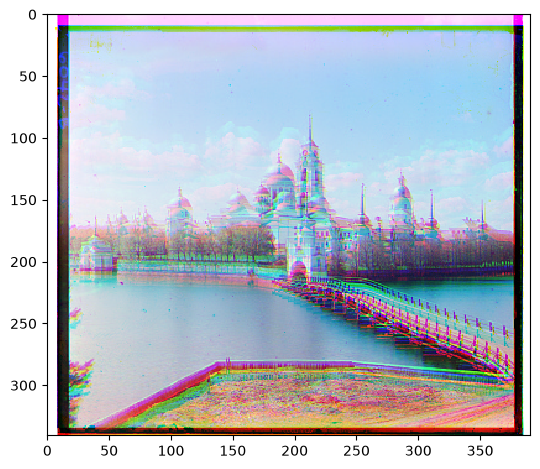

/var/folders/d2/8xxcksw968qc75dtqjt32_mc0000gn/T/ipykernel_19016/200207943.py:28: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_out)
/var/folders/d2/8xxcksw968qc75dtqjt32_mc0000gn/T/ipykernel_19016/200207943.py:29: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


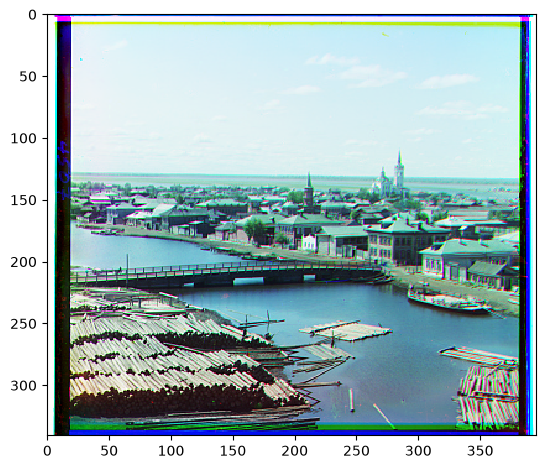

/var/folders/d2/8xxcksw968qc75dtqjt32_mc0000gn/T/ipykernel_19016/200207943.py:28: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_out)
/var/folders/d2/8xxcksw968qc75dtqjt32_mc0000gn/T/ipykernel_19016/200207943.py:29: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


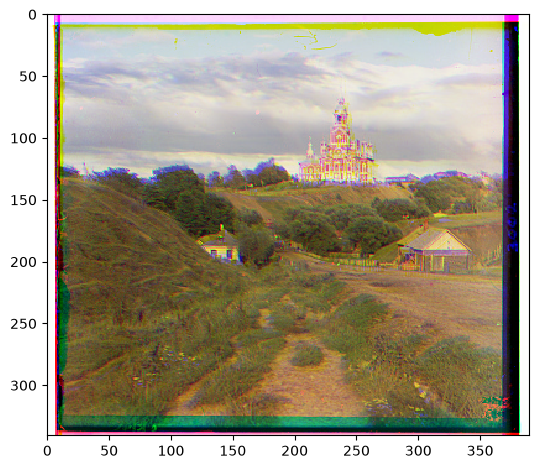

KeyboardInterrupt: 

In [ ]:
for path in glob.glob('CS180_fa2026_proj1_data/*.jpg') + \
        glob.glob('CS180_fa2026_proj1_data/*.tif'):
    im = skio.imread(path)
    im = sk.img_as_float(im)
    
    # compute the height of each part (just 1/3 of total)
    height = np.floor(im.shape[0] / 3.0).astype(int)

    # separate color channels
    b = im[:height]
    g = im[height: 2*height]
    r = im[2*height: 3*height]

    # align the images
    # functions that might be useful for aligning the images include:
    # np.roll, np.sum, sk.transform.rescale (for multiscale)

    ag = align(b, g)
    ar = align(b, r)
    # create a color image
    im_out = np.dstack([ar, ag, b])

    # save the image
    name = os.path.splitext(os.path.basename(path))[0]
    skio.imsave(f'output/out_{name}.jpg', img_as_ubyte(im_out))

    # display the image
    skio.imshow(im_out)
    skio.show()